### Uses R v4.3.3.

# Differential expression analysis of RNA-seq Data using edgeR: A comparative study of Ryan datasets reflecting healthy versus recovered patients with LC symptoms classified as severe or critical.

### Introduction:

This analysis focuses on the DEGs analysis of three phenotypic attributes from one dataset (Ryan Et al) was reprocessed along with the other datasets in the compendium using the Bwb software.  The edgeR package that analyzed the output of Bwb data was set to FDR < 0.05 and a log2foldchange = 1.25. The DEGs comparison is illustrated in the figure below as pathway (iii) with the overall aim being to identify key genes that reflect significant expression differences between the two groups of participants (Healthy versus those healed from active COVID-19 and reporting Long-Covid (LC) signs and symptoms that were classified as severe or critical).  

The clincal scores were based on the signs and symptoms as detailed in "NIH. Clinical Spectrum of SARS-CoV-2 Infection 2021" where 5 = "asymptomatic", 4 = "mild", 3 = "moderate", 2 = "severe", and 1 = "critical".

### Specific Objectives

1. **Data Processing** - Importing and cleaning the metadata
2. **Filtering out Low Expression Genes** - Dropping genes with low expression to improve statistical power
3. **Normalization** - Using Trimmed Mean of M-values to adjust for differences in sequencing depth
4. **Differential expression analysis** - Using a negative binomial exact test (see here for the packge documentation)
5. **Extract and interpret top DEGs** - to highlight their biological relevance
6. **Set-up for downstream GSEA** - use the outputs to create rank lists for GSEA (different notebook)



![Study design](./images/Study_design.png)

### Uncomment to install BiocManager and DESeq2.  Comment back out after running once.  It's not necessary to reinstall every time the notebook is ran.

In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")
# BiocManager::install(version = "3.18")
# BiocManager::install(c("edgeR"))

### Uncomment out each package individually and run the cell to install each package.  Do this one at a time and watch the terminal output to see if any additional dependencies need to be installed on your system.  This is espeically true on Linux where you need to install other packages from the package manager.

In [2]:
# install.packages('readr', version='2.1.5')
# install.packages('dplyr', version='1.1.4')
# install.packages('plotly', version='4.10.4')

In [3]:
library(readr)
library(dplyr)

library(edgeR)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: limma



### Data Processing - Importing and cleaning the metadata

In this section, we import the normalized counts matrix from Bwb's uniform processing as our input for the Ryan Et part of the dataset.  We will later filter it to keep only the relevant samples using our sample sheet created using a different notebook.

The input file is cleaned by removing suffixes from the column headers to keep the same convention with all other notebooks in this analsyis.  We will sort the columns for consistency and then perform a sanity check by display the head to show only afew rows of the output.

## Change the Ryan Gene Counts location by updating the read.csv() value.

In [4]:
# Read Ryan counts
ryan.counts <- as.matrix(read.csv("./data/Ryan/genesCounts.csv", sep="\t",row.names="Name"))

# Edit sample names in dataframe
colnames(ryan.counts) <- sapply(strsplit(colnames(ryan.counts), "_"), `[`, 1)

# Order the dataframe by column name
ryan.counts <- ryan.counts[, sort(colnames(ryan.counts))]

head(ryan.counts)

,SRR14076246,SRR14076247,SRR14076248,SRR14076249,SRR14076250,SRR14076251,SRR14076252,SRR14076253,SRR14076254,SRR14076255,⋯,SRR15510595,SRR15510596,SRR15510597,SRR15510598,SRR15510599,SRR15510600,SRR15510601,SRR15510602,SRR15510603,SRR15510604
ENSG00000268674,0,0,0,0,0,0,1,0,2,1,⋯,2,0,5,0,0,0,0,1,1,0
ENSG00000271254,72,50,203,199,96,130,75,76,228,181,⋯,215,318,169,146,269,241,257,154,279,94
ENSG00000275063,2,5,0,0,0,0,5,8,1,0,⋯,9,0,1,4,5,0,0,0,2,0
ENSG00000277856,0,1,0,0,0,0,2,1,0,0,⋯,0,1,0,1,1,0,0,0,0,0
ENSG00000276345,0,0,6,0,0,8,111,72,151,113,⋯,0,0,0,0,5,2,8,432,5,0
ENSG00000278633,4,0,7,7,2,0,10,0,12,2,⋯,9,8,22,1,11,16,19,2,7,0


In [5]:
# Sanity check
dim(ryan.counts)

[1] 38592   152

### Loading the metadata

Now that we have the normalized data with a counts matrix, we need the metadata which will guide us in subsetting our data with respect to clinical attributes like presence or absence of LC, LC severity classification etc. We include the sample sheets for our desired comparisons which are those that were healthy and that have healed from acute COVID-19 and have LC signs and symptoms classified as severe or critical.

We also prepare the metadata dataset by removing the extra index column, combining all relevant sample sheets for inclusion, then sorting by sample name "Run".

## Change the Compendium metadata locations by updating the read_tsv() values.

In [6]:
# Read Andrew's Compendium data: Group A - Ryan
sample.sheet.healthy.af = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_af.csv")
sample.sheet.healthy.am = read_tsv("./Andrews_Compendium/output/sample_sheet_healthy_am.csv")

# Remove first column from dataframes
sample.sheet.healthy.af <- sample.sheet.healthy.af[c(2:length(colnames(sample.sheet.healthy.af)))]
sample.sheet.healthy.am <- sample.sheet.healthy.am[c(2:length(colnames(sample.sheet.healthy.am)))]

# Concatenate dataframes
ryan.sample.sheet.healthy <- rbind(sample.sheet.healthy.af, sample.sheet.healthy.am)

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.healthy <- arrange(ryan.sample.sheet.healthy, Run)

ryan.sample.sheet.healthy

New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 7 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (26): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


In [7]:
# Reduce and convert ryan_sample_sheet_healthy into sheet that can be concatenated
ryan.sample.sheet.healthy.reduced = ryan.sample.sheet.healthy[c("Run", "disease_severity")]
                                            
ryan.sample.sheet.healthy.reduced                         

Run,disease_severity
<chr>,<chr>
SRR14076274,Healthy
SRR14076275,Healthy
SRR14076280,Healthy
SRR14076281,Healthy
SRR14076285,Healthy
SRR14076286,Healthy
SRR14076291,Healthy
SRR14076292,Healthy
SRR14076319,Healthy


Next is to combine all the sample sheets that contain data from LC servere or critical groups.

## Change the Compendium metadata locations by updating the read_tsv() values.

In [8]:
# Read Andrew's Compendium data: Group E - Ryan
sample.sheet.severe.e12f = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e12f.csv")
sample.sheet.severe.e12m = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e12m.csv")
sample.sheet.severe.e16f = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e16f.csv")
sample.sheet.severe.e16m = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e16m.csv")
sample.sheet.severe.e24f = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e24f.csv")
sample.sheet.severe.e24m = read_tsv("./Andrews_Compendium/output/sample_sheet_severe_e24m.csv")

# Remove first column from dataframes
sample.sheet.severe.e12f <- sample.sheet.severe.e12f[c(2:length(colnames(sample.sheet.severe.e12f)))]
sample.sheet.severe.e12m <- sample.sheet.severe.e12m[c(2:length(colnames(sample.sheet.severe.e12m)))]
sample.sheet.severe.e16f <- sample.sheet.severe.e16f[c(2:length(colnames(sample.sheet.severe.e16f)))]
sample.sheet.severe.e16m <- sample.sheet.severe.e16m[c(2:length(colnames(sample.sheet.severe.e16m)))]
sample.sheet.severe.e24f <- sample.sheet.severe.e24f[c(2:length(colnames(sample.sheet.severe.e24f)))]
sample.sheet.severe.e24m <- sample.sheet.severe.e24m[c(2:length(colnames(sample.sheet.severe.e24m)))]

# Concatenate dataframes
sample.sheet.severe.e12 <- rbind(sample.sheet.severe.e12f, sample.sheet.severe.e12m)
sample.sheet.severe.e16 <- rbind(sample.sheet.severe.e16f, sample.sheet.severe.e16m)
sample.sheet.severe.e24 <- rbind(sample.sheet.severe.e24f, sample.sheet.severe.e24m)

ryan.sample.sheet.severe <- do.call("rbind", list(sample.sheet.severe.e12, sample.sheet.severe.e16, sample.sheet.severe.e24))

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.severe <- arrange(ryan.sample.sheet.severe, Run)

ryan.sample.sheet.severe

New names:
• `` -> `...1`
Rows: 0 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (35): ...1, Run, Age, Assay Type, AvgSpotLen, Bases, BioProject, BioSamp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 2 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 1 Columns: 35
── Column specification ────────────────────────────────────────────────────

Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076248,65.90000,RNA-Seq,300,16702272600,PRJNA717662,SAMN18500007,5433791391,GEO,public,⋯,1,GSM5212318,male,Peripheral blood,SRP312283,15-048,16wpi,Peripheral blood,8.8,Sample-17
SRR14076249,65.90000,RNA-Seq,300,16997697600,PRJNA717662,SAMN18500006,5517356272,GEO,public,⋯,1,GSM5212319,male,Peripheral blood,SRP312283,15-048,24wpi,Peripheral blood,8.5,Sample-25
SRR14076254,66.20000,RNA-Seq,300,19998498900,PRJNA717662,SAMN18500001,6500019419,GEO,public,⋯,1,GSM5212324,female,Peripheral blood,SRP312283,15-018,16wpi,Peripheral blood,8.8,Sample-18
SRR14076255,66.20000,RNA-Seq,300,20133594900,PRJNA717662,SAMN18500000,6524607837,GEO,public,⋯,1,GSM5212325,female,Peripheral blood,SRP312283,15-018,24wpi,Peripheral blood,8.8,Sample-26
SRR14076262,70.50000,RNA-Seq,300,18438799200,PRJNA717662,SAMN18500023,5986185391,GEO,public,⋯,1,GSM5212332,male,Peripheral blood,SRP312283,15-005,16wpi,Peripheral blood,8.8,Sample-35
SRR14076263,70.50000,RNA-Seq,300,17271192300,PRJNA717662,SAMN18500022,5619437612,GEO,public,⋯,1,GSM5212333,male,Peripheral blood,SRP312283,15-005,24wpi,Peripheral blood,8.2,Sample-43
SRR14076278,50.50000,RNA-Seq,300,19368642000,PRJNA717662,SAMN18499984,6340470051,GEO,public,⋯,1,GSM5212348,male,Peripheral blood,SRP312283,15-036,16wpi,Peripheral blood,9.0,Sample-22
SRR14076279,50.50000,RNA-Seq,300,17565948000,PRJNA717662,SAMN18499983,5731948287,GEO,public,⋯,1,GSM5212349,male,Peripheral blood,SRP312283,15-036,24wpi,Peripheral blood,9.1,Sample-30
SRR14076311,70.00000,RNA-Seq,300,15565864200,PRJNA717662,SAMN18499957,5098610122,GEO,public,⋯,1,GSM5212381,male,Peripheral blood,SRP312283,15-017,16wpi,Peripheral blood,9.1,Sample-68


In [9]:
# Reduce and convert ryan_sample_sheet_severe into sheet that can be concatenated
ryan.sample.sheet.severe.reduced = ryan.sample.sheet.severe[c("Run", "disease_severity")]

ryan.sample.sheet.severe.reduced$disease_severity <- rep("Severe/Critial", length(ryan.sample.sheet.severe.reduced$disease_severity))
                                            
ryan.sample.sheet.severe.reduced             

Run,disease_severity
<chr>,<chr>
SRR14076248,Severe/Critial
SRR14076249,Severe/Critial
SRR14076254,Severe/Critial
SRR14076255,Severe/Critial
SRR14076262,Severe/Critial
SRR14076263,Severe/Critial
SRR14076278,Severe/Critial
SRR14076279,Severe/Critial
SRR14076311,Severe/Critial


Next, we build a dataframe comprising of all the sample sheets with severe or critical cases of LC

## Change the Compendium metadata locations by updating the read_tsv() values.

In [10]:
# Read Andrew's Compendium data: Group F - Ryan
sample.sheet.critical.f12f = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f12f.csv")
sample.sheet.critical.f12m = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f12m.csv")
sample.sheet.critical.f16f = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f16f.csv")
sample.sheet.critical.f16m = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f16m.csv")
sample.sheet.critical.f24f = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f24f.csv")
sample.sheet.critical.f24m = read_tsv("./Andrews_Compendium/output/sample_sheet_critical_f24m.csv")

# Remove first column from dataframes
sample.sheet.critical.f12f <- sample.sheet.critical.f12f[c(2:length(colnames(sample.sheet.critical.f12f)))]
sample.sheet.critical.f12m <- sample.sheet.critical.f12m[c(2:length(colnames(sample.sheet.critical.f12m)))]
sample.sheet.critical.f16f <- sample.sheet.critical.f16f[c(2:length(colnames(sample.sheet.critical.f16f)))]
sample.sheet.critical.f16m <- sample.sheet.critical.f16m[c(2:length(colnames(sample.sheet.critical.f16m)))]
sample.sheet.critical.f24f <- sample.sheet.critical.f24f[c(2:length(colnames(sample.sheet.critical.f24f)))]
sample.sheet.critical.f24m <- sample.sheet.critical.f24m[c(2:length(colnames(sample.sheet.critical.f24m)))]

# Concatenate dataframes
sample.sheet.critical.f12 <- rbind(sample.sheet.critical.f12f, sample.sheet.critical.f12m)
sample.sheet.critical.f16 <- rbind(sample.sheet.critical.f16f, sample.sheet.critical.f16m)
sample.sheet.critical.f24 <- rbind(sample.sheet.critical.f24f, sample.sheet.critical.f24m)

ryan.sample.sheet.critical <- do.call("rbind", list(sample.sheet.critical.f12, sample.sheet.critical.f16, sample.sheet.critical.f24))

# Sort dataframe by Run (Sample) column
ryan.sample.sheet.critical <- arrange(ryan.sample.sheet.critical, Run)

ryan.sample.sheet.critical

New names:
• `` -> `...1`
Rows: 2 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 2 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (25): Run, Assay Type, BioProject, BioSample, Center Name, Consent, DAT...
dbl   (7): ...1, Age, AvgSpotLen, Bases, Bytes, version, RIN
lgl   (1): Sample_Number
dttm  (2): ReleaseDate, create_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076250,53.40000,RNA-Seq,300,17635473000,PRJNA717662,SAMN18500005,5716280316,GEO,public,⋯,1,GSM5212320,male,Peripheral blood,SRP312283,15-027,16wpi,Peripheral blood,8.9,Sample-33
SRR14076251,53.40000,RNA-Seq,300,18009702900,PRJNA717662,SAMN18500004,5866790779,GEO,public,⋯,1,GSM5212321,male,Peripheral blood,SRP312283,15-027,24wpi,Peripheral blood,8.9,Sample-41
SRR14076264,77.50000,RNA-Seq,300,18521184000,PRJNA717662,SAMN18500021,6030483277,GEO,public,⋯,1,GSM5212334,male,Peripheral blood,SRP312283,15-022,16wpi,Peripheral blood,9.0,Sample-4
SRR14076265,77.50000,RNA-Seq,300,19329684600,PRJNA717662,SAMN18500020,6263845716,GEO,public,⋯,1,GSM5212335,male,Peripheral blood,SRP312283,15-022,24wpi,Peripheral blood,7.8,Sample-12
SRR14076268,64.30000,RNA-Seq,300,17331475200,PRJNA717662,SAMN18500017,5649739394,GEO,public,⋯,1,GSM5212338,female,Peripheral blood,SRP312283,15-035,16wpi,Peripheral blood,8.4,Sample-36
SRR14076269,64.30000,RNA-Seq,300,22446302400,PRJNA717662,SAMN18500016,7271216630,GEO,public,⋯,1,GSM5212339,female,Peripheral blood,SRP312283,15-035,24wpi,Peripheral blood,6.7,Sample-44
SRR14076276,72.10000,RNA-Seq,300,16361598300,PRJNA717662,SAMN18499986,5334742372,GEO,public,⋯,1,GSM5212346,female,Peripheral blood,SRP312283,15-007,16wpi,Peripheral blood,9.1,Sample-6
SRR14076277,72.10000,RNA-Seq,300,18620965800,PRJNA717662,SAMN18499985,6054464447,GEO,public,⋯,1,GSM5212347,female,Peripheral blood,SRP312283,15-007,24wpi,Peripheral blood,8.7,Sample-14
SRR14076284,68.00000,RNA-Seq,300,18415633500,PRJNA717662,SAMN18499910,5967397180,GEO,public,⋯,1,GSM5212354,male,Peripheral blood,SRP312283,15-068,24wpi,Peripheral blood,9.1,Sample-31


In [11]:
# Reduce and convert ryan_sample_sheet_critical into sheet that can be concatenated
ryan.sample.sheet.critical.reduced = ryan.sample.sheet.critical[c("Run", "disease_severity")]

ryan.sample.sheet.critical.reduced$disease_severity <- rep("Severe/Critial", length(ryan.sample.sheet.critical.reduced$disease_severity))
                                            
ryan.sample.sheet.critical.reduced

Run,disease_severity
<chr>,<chr>
SRR14076250,Severe/Critial
SRR14076251,Severe/Critial
SRR14076264,Severe/Critial
SRR14076265,Severe/Critial
SRR14076268,Severe/Critial
SRR14076269,Severe/Critial
SRR14076276,Severe/Critial
SRR14076277,Severe/Critial
SRR14076284,Severe/Critial


In [12]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.a.counts.of.interest <- ryan.counts[, ryan.sample.sheet.healthy$Run]

head(ryan.group.a.counts.of.interest)

,SRR14076274,SRR14076275,SRR14076280,SRR14076281,SRR14076285,SRR14076286,SRR14076291,SRR14076292,SRR14076319,SRR14076320,SRR14076325,SRR14076326,SRR14076331,SRR14076332
ENSG00000268674,0,0,0,2,0,0,0,0,1,0,0,0,0,1
ENSG00000271254,153,68,59,141,87,127,97,161,129,149,71,271,138,178
ENSG00000275063,0,0,0,0,0,2,5,10,14,1,8,2,8,0
ENSG00000277856,0,0,0,0,0,4,0,0,1,1,1,1,1,0
ENSG00000276345,0,110,80,0,2,2,0,239,0,2,7,0,140,149
ENSG00000278633,0,14,2,6,2,0,0,0,6,0,1,12,0,0


In [13]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.e.counts.of.interest <- ryan.counts[, ryan.sample.sheet.severe$Run]

head(ryan.group.e.counts.of.interest)

,SRR14076248,SRR14076249,SRR14076254,SRR14076255,SRR14076262,SRR14076263,SRR14076278,SRR14076279,SRR14076311,SRR14076312,SRR14076321,SRR14076322,SRR15510542,SRR15510546
ENSG00000268674,0,0,2,1,0,0,1,3,0,1,2,3,0,0
ENSG00000271254,203,199,228,181,226,183,111,108,126,120,250,230,450,284
ENSG00000275063,0,0,1,0,1,0,0,0,3,3,4,10,0,0
ENSG00000277856,0,0,0,0,0,0,0,0,0,1,0,1,0,0
ENSG00000276345,6,0,151,113,126,86,0,2,6,0,2,15,0,274
ENSG00000278633,7,7,12,2,15,34,13,13,0,6,3,5,2,22


In [14]:
# Create dataframe from Gene Counts that only contains samples from compendium
ryan.group.f.counts.of.interest <- ryan.counts[, ryan.sample.sheet.critical$Run]

head(ryan.group.f.counts.of.interest)

,SRR14076250,SRR14076251,SRR14076264,SRR14076265,SRR14076268,SRR14076269,SRR14076276,SRR14076277,SRR14076284,SRR14076327,SRR14076328,SRR15510548,SRR15510565,SRR15510569,SRR15510582
ENSG00000268674,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0
ENSG00000271254,96,130,165,139,97,112,204,154,40,87,73,232,212,162,144
ENSG00000275063,0,0,2,3,6,11,0,0,2,0,0,1,2,0,12
ENSG00000277856,0,0,0,0,2,0,0,1,0,0,0,2,0,0,1
ENSG00000276345,0,8,2,0,0,0,0,2,1,145,169,2,2,2,6
ENSG00000278633,2,0,9,5,8,10,9,2,14,0,2,5,1,1,1


Next, we combine the all three phenotypic data (healthy, severe LC, and critical LC) to have a comprehensive list of these clinical attributes.

In [15]:
# Concatinate Ryan and Yin counts of interest
counts.of.interest <- do.call("cbind", list(ryan.group.a.counts.of.interest, ryan.group.e.counts.of.interest, ryan.group.f.counts.of.interest))

dim(counts.of.interest)

[1] 38592    43

We then perform a filtering step that removes any rows of genes that conatin all zeros in every column. This will not affect analysis negatively and will save on computational resources during iterative analysis. As we can see below. This step reduced the dimensions of the dataframe to 34,572 genes (rows) from 38,592 while keeping the 43 total samples.

In [16]:
# Remove Genes that only contain 0s
counts.of.interest.filtered <- counts.of.interest[apply(counts.of.interest != 0, 1, sum) != 0,]
dim(counts.of.interest.filtered)

[1] 34572    43

In [17]:
# Concatinate Ryan and Yin metadata
metadata <- rbind(ryan.sample.sheet.healthy, ryan.sample.sheet.severe, ryan.sample.sheet.critical)

metadata$disease_severity <- factor(metadata$disease_severity)

metadata

Run,Age,Assay Type,AvgSpotLen,Bases,BioProject,BioSample,Bytes,Center Name,Consent,⋯,version,Sample Name,sex,source_name,SRA Study,subject_id,Timepoint,tissue,RIN,Sample_Number
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
SRR14076274,65.00000,RNA-Seq,300,17132068500,PRJNA717662,SAMN18499988,5577168394,GEO,public,⋯,1,GSM5212344,female,Peripheral blood,SRP312283,HC1,Control,Peripheral blood,8.5,Sample-37
SRR14076275,55.00000,RNA-Seq,300,18290564100,PRJNA717662,SAMN18499987,5941597180,GEO,public,⋯,1,GSM5212345,male,Peripheral blood,SRP312283,HC6,Control,Peripheral blood,8.8,Sample-45
SRR14076280,34.00000,RNA-Seq,300,15407664600,PRJNA717662,SAMN18499982,5011739338,GEO,public,⋯,1,GSM5212350,male,Peripheral blood,SRP312283,HC2,Control,Peripheral blood,8.0,Sample-38
SRR14076281,48.00000,RNA-Seq,300,15462196200,PRJNA717662,SAMN18499981,5036146643,GEO,public,⋯,1,GSM5212351,male,Peripheral blood,SRP312283,HC7,Control,Peripheral blood,8.5,Sample-46
SRR14076285,63.00000,RNA-Seq,300,17168881500,PRJNA717662,SAMN18499909,5593291175,GEO,public,⋯,1,GSM5212355,female,Peripheral blood,SRP312283,HC4,Control,Peripheral blood,8.4,Sample-39
SRR14076286,27.00000,RNA-Seq,300,18766087200,PRJNA717662,SAMN18499946,6099144065,GEO,public,⋯,1,GSM5212356,male,Peripheral blood,SRP312283,HC8,Control,Peripheral blood,8.6,Sample-47
SRR14076291,52.00000,RNA-Seq,300,15353712600,PRJNA717662,SAMN18499941,4995757233,GEO,public,⋯,1,GSM5212361,female,Peripheral blood,SRP312283,HC5,Control,Peripheral blood,7.8,Sample-40
SRR14076292,54.00000,RNA-Seq,300,17904928800,PRJNA717662,SAMN18499940,5852173368,GEO,public,⋯,1,GSM5212362,male,Peripheral blood,SRP312283,HC9,Control,Peripheral blood,8.5,Sample-48
SRR14076319,70.00000,RNA-Seq,300,15545828400,PRJNA717662,SAMN18499928,5062379739,GEO,public,⋯,1,GSM5212389,male,Peripheral blood,SRP312283,HC3,Control,Peripheral blood,8.5,Sample-85


Next, we will create a DGEList object which will be the foundation of our analysis. This method (See help() of 
the package) will help us filter genes based on expression levels, normalize the gene counts, create a design matrix
for comparison, then it will estimate dispersion (which is the variance in gene expression). After this, it will perform statistical testing.


In [18]:
# Defining two groups and assigning to the variable "group"
group <- factor(c(rep(1,14), rep(2, 29)))

In [19]:
# Preparing the data for normalization, filtering, and DEA,  Assigning it to a variable 'y'
y <- DGEList(counts=counts.of.interest.filtered, group=group)

In [20]:
# Filtering out genes to keep only those with more than 3 copies per million in at least 5 samples.
dim(y)
keep <- rowSums(cpm(y)>3) > 5
table(keep)

[1] 34572    43

keep
FALSE  TRUE 
21255 13317 

In [21]:
# Removing those genes that were filter out to only keep the 13,317 genes
y <- y[keep, , keep.lib.sizes=FALSE]
tokeep = rownames(y)
dim(y)

[1] 13317    43

In [22]:
# Normalization with edgeR
y <- calcNormFactors(y)

In [23]:
# Creating the Design matrix
design <- model.matrix(~group)

In [24]:
# Estimating dispersions
y <- estimateDisp(y)

Using classic mode.



In [25]:
# Inferring differential expression
et <- exactTest(y)

In [26]:
# Subsetting top DEGs
top20.genes <- rownames(topTags(et, n=20)$table)
top50.genes <- rownames(topTags(et, n=50)$table)
top100.genes <- rownames(topTags(et, n=100)$table)

In [27]:
# Obtaining expression levels of top 20 genes from counts of interest
raw.cnts.top20 <- counts.of.interest[top20.genes, ]

In [28]:
# Sanity check of the column headers
colnames(counts.of.interest.filtered)

[1] "SRR14076274" "SRR14076275" "SRR14076280" "SRR14076281" "SRR14076285"
 [6] "SRR14076286" "SRR14076291" "SRR14076292" "SRR14076319" "SRR14076320"
[11] "SRR14076325" "SRR14076326" "SRR14076331" "SRR14076332" "SRR14076248"
[16] "SRR14076249" "SRR14076254" "SRR14076255" "SRR14076262" "SRR14076263"
[21] "SRR14076278" "SRR14076279" "SRR14076311" "SRR14076312" "SRR14076321"
[26] "SRR14076322" "SRR15510542" "SRR15510546" "SRR14076250" "SRR14076251"
[31] "SRR14076264" "SRR14076265" "SRR14076268" "SRR14076269" "SRR14076276"
[36] "SRR14076277" "SRR14076284" "SRR14076327" "SRR14076328" "SRR15510548"
[41] "SRR15510565" "SRR15510569" "SRR15510582"

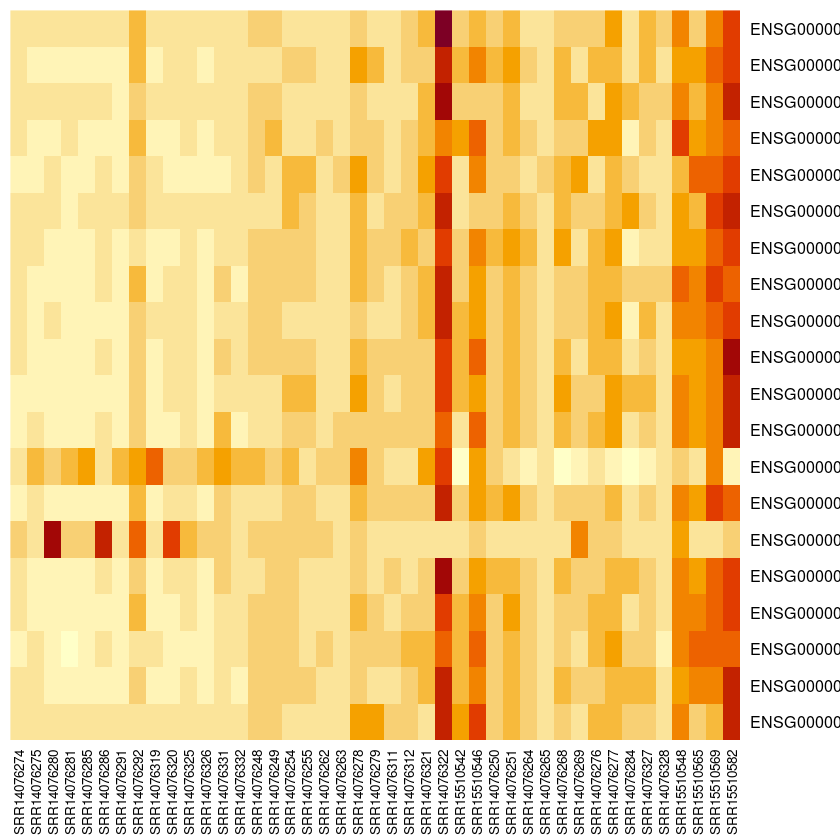

In [29]:
# Heatmap visualization of top 20 genes
heatmap(as.matrix(raw.cnts.top20), Colv=NA, Rowv=NA)

In [30]:
# Obtaining expression levels of top 50 genes from counts of interest
raw.cnts.top50 <- counts.of.interest[top50.genes, ]

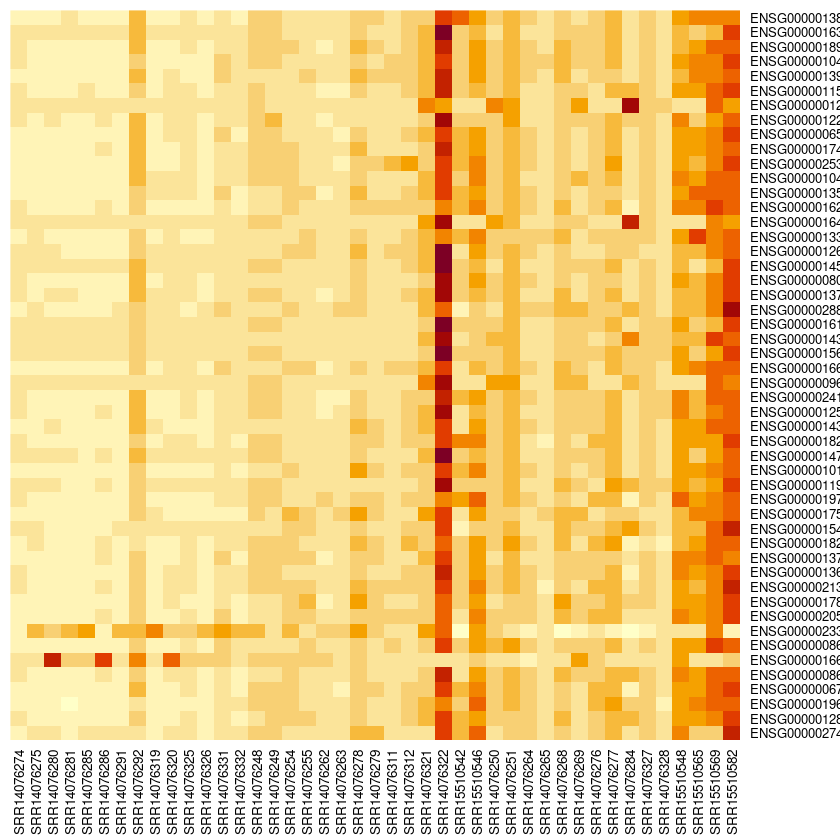

In [31]:
# Heatmap visualization of top 50 genes
heatmap(as.matrix(raw.cnts.top50), Colv=NA, Rowv=NA)

In [32]:
# Obtaining expression levels of top 100 genes from counts of interest
raw.cnts.top100 <- counts.of.interest[top100.genes, ]

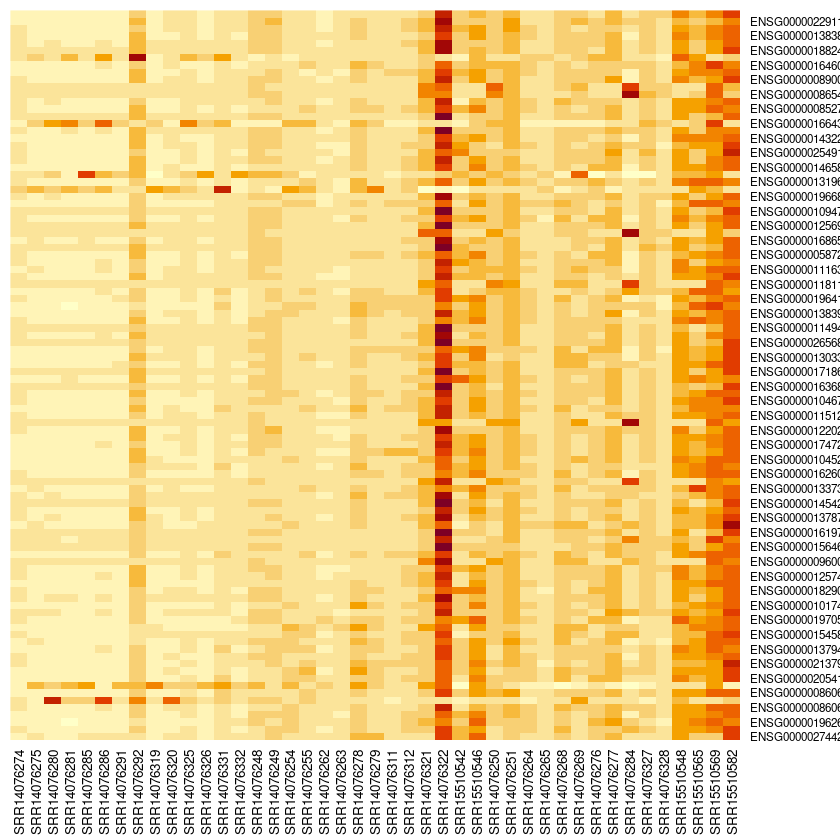

In [33]:
# Heatmap visualization of top 100 genes
heatmap(as.matrix(raw.cnts.top100), Colv=NA, Rowv=NA)

In [34]:
# Extracting the top differentially expressed genes
deg_results_AvsEF <- topTags(et, n = Inf)$table
head(deg_results_AvsEF)

,logFC,logCPM,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>
ENSG00000274422,1.7826905,2.699729,2.323045e-08,0.0003093599
ENSG00000128708,0.6618762,3.838171,9.578361e-08,0.0004201335
ENSG00000196268,0.3842433,5.856205,1.091421e-07,0.0004201335
ENSG00000067334,0.5314670,4.774996,1.422294e-07,0.0004201335
ENSG00000086065,0.8680235,3.867630,1.961050e-07,0.0004201335
ENSG00000166831,-1.5632992,1.146361,2.078331e-07,0.0004201335


### Notice

The next slide can be saved as a .csv excel spread sheet by uncommenting the code snippet while leaving the comment with the '#'.

In [35]:
# # Ensure row names (gene IDs) are saved as a column
# deg_results_AvsEF$GeneID <- rownames(deg_results_AvsEF)

# # Save the file with GeneID included
# write.csv(deg_results_AvsEF, file = file.path(getwd(), "deg_results_AvsEF.csv"), row.names = FALSE)
